In [101]:
import librosa
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import scipy

import soundfile
import pretty_midi
import IPython
import fluidsynth

import torch

import random

from types import SimpleNamespace

import os

import soundfile

# INITIAL TESTING

In [20]:
signal, sampling_rate = librosa.load('c-major.mp3')

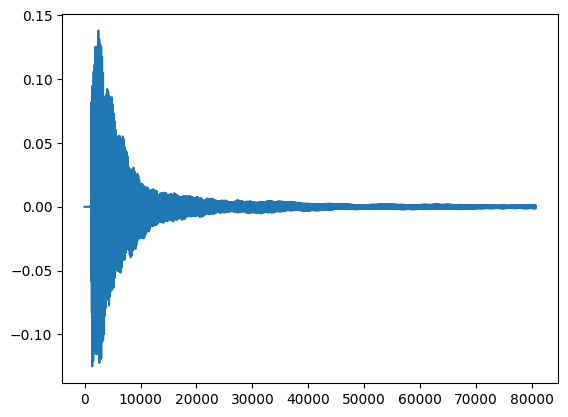

In [21]:
plt.plot(signal)
plt.show()

In [22]:
audio_transformed = np.abs(librosa.cqt(signal, sr=sampling_rate))
audio_transformed.shape

(84, 158)

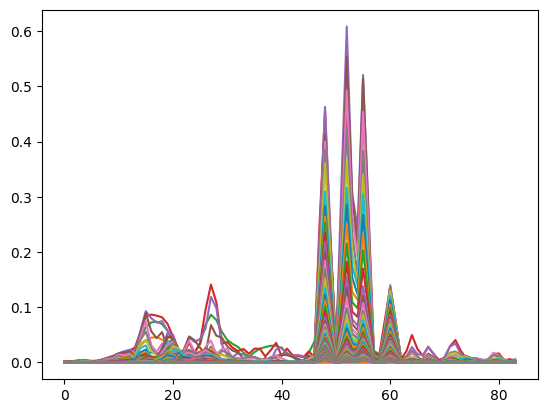

In [23]:
plt.plot(audio_transformed)
plt.show()

In [24]:
audio_transformed

array([[1.83113222e-03, 1.92781002e-03, 1.96746970e-03, ...,
        7.80675782e-06, 8.40006305e-06, 8.69069845e-06],
       [1.86916080e-03, 1.91222958e-03, 1.84669299e-03, ...,
        8.19572415e-06, 8.83796292e-06, 9.12733685e-06],
       [2.33069481e-03, 2.58737011e-03, 2.74930219e-03, ...,
        8.09935227e-06, 8.88050727e-06, 9.25889526e-06],
       ...,
       [5.68294706e-13, 1.15613465e-11, 4.09396052e-05, ...,
        4.50371232e-07, 1.82258589e-07, 1.15652732e-07],
       [7.02748203e-14, 2.49347539e-11, 8.81274973e-05, ...,
        6.40702282e-08, 2.54696999e-07, 3.61108562e-07],
       [2.79742565e-13, 2.09375746e-11, 6.76350319e-05, ...,
        2.52166870e-07, 1.90235909e-07, 7.29264116e-08]], dtype=float32)

In [25]:
def plot_audio_cqt(file_name, start=0, stop=None):
    y, sr = librosa.load(file_name)
    y = y[int(sr * start): int(sr * stop)] if stop else y[int(sr * start):]
    C = np.abs(librosa.cqt(y, sr=sr, bins_per_octave=12))
    fig, ax = plt.subplots()
    img = librosa.display.specshow(librosa.amplitude_to_db(C, ref=np.max),
                                sr=sr, x_axis='time', y_axis='cqt_note', ax=ax)
    ax.set_title('Constant-Q power spectrum')
    fig.colorbar(img, ax=ax, format="%+2.0f dB")

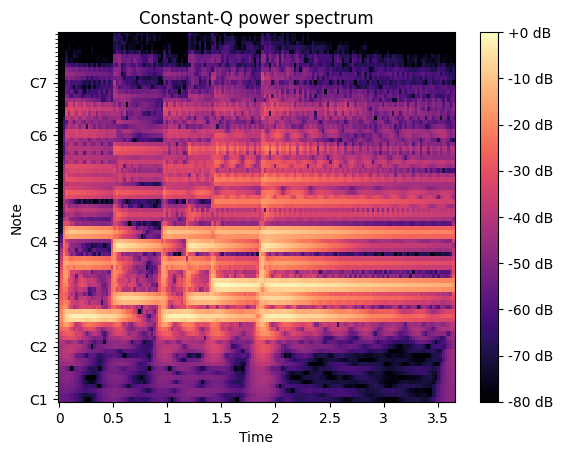

In [26]:
plot_audio_cqt('g-major.mp3')

In [27]:
def file_to_cqt(file_name):
    y, sr = librosa.load(file_name)
    print(sr)
    print(len(y))
    C = np.abs(librosa.cqt(y, sr=sr, bins_per_octave=12))
    return C, sr

In [28]:
C, sr = file_to_cqt('c-major.mp3')
C.shape

22050
80640


(84, 158)

In [29]:
piano_notes = []

piano_notes += ['A0', 'Bb0', 'B0']

for i in range(1,8):
    piano_notes += [f'C{i}',
                    f'Db{i}',
                    f'D{i}',
                    f'Eb{i}',
                    f'E{i}',
                    f'F{i}',
                    f'Gb{i}',
                    f'G{i}',
                    f'Ab{i}',
                    f'A{i}', 
                    f'Bb{i}',
                    f'B{i}']

piano_notes += ['C8']

In [30]:
midi = pretty_midi.PrettyMIDI()
piano_program = pretty_midi.instrument_name_to_program('Acoustic Grand Piano')
piano = pretty_midi.Instrument(program=piano_program)

In [31]:
for _ in range(0, 5):
    random_note = piano_notes[random.randint(0, len(piano_notes))]

    note_number = pretty_midi.note_name_to_number(random_note)

    start = random.uniform(0, 2)
    end = start + random.uniform (0.1, 10)

    note = pretty_midi.Note(velocity=100, pitch=note_number, start=start, end=end)
    if note not in piano.notes:
        piano.notes.append(note)

In [32]:
piano.notes


[Note(start=0.680437, end=4.591227, pitch=69, velocity=100),
 Note(start=1.755301, end=8.179049, pitch=54, velocity=100),
 Note(start=1.323785, end=2.182193, pitch=36, velocity=100),
 Note(start=1.034354, end=1.885118, pitch=42, velocity=100),
 Note(start=0.693266, end=5.711178, pitch=57, velocity=100)]

C:\Users\Philip\AppData\Local\Temp\ipykernel_103808\1995535097.py:3: UserWarning: Frequency axis exceeds Nyquist. Did you remember to set all spectrogram parameters in specshow?
  librosa.display.specshow(pm.get_piano_roll(fs)[start_pitch:end_pitch],


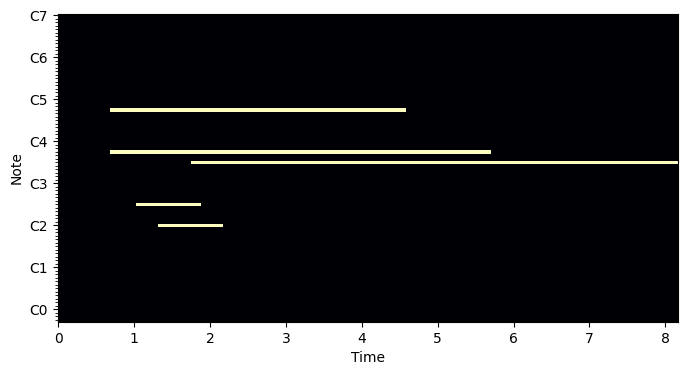

In [33]:
def plot_piano_roll(pm, start_pitch, end_pitch, fs=100):
    # Use librosa's specshow function for displaying the piano roll
    librosa.display.specshow(pm.get_piano_roll(fs)[start_pitch:end_pitch],
                             hop_length=1, sr=fs, x_axis='time', y_axis='cqt_note',
                             fmin=pretty_midi.note_number_to_hz(start_pitch))

plt.figure(figsize=(8, 4))
plot_piano_roll(piano, 9, 97)

In [34]:
def midi_to_audio_file(midi_obj, sample_rate: int, file_name: str, synthesizer: str = None):

    audio_data = midi_obj.fluidsynth(synthesizer=synthesizer)

    clean_audio_obj = IPython.display.Audio(audio_data, rate=sample_rate)
    with open(file_name, "wb") as f:
        f.write(clean_audio_obj.data)

In [35]:
sample_rate = int(22050)
midi_to_audio_file(midi_obj=piano, sample_rate=sample_rate, file_name="test_midi.mp3")


In [36]:
C, sr = file_to_cqt('test_midi.mp3')


22050
404797


In [37]:
"""
midi input to array of information for processing

sr = sample rate
audio_length = length of entire audio (sr * seconds in video)
step_size = steps in sr for the cqt transform (default is 512 iirc)

time_steps = (audio_length / step_size) + 1

"""
NOTE_ONSET = 1
NOTE_CONTINUED = 2
NOTE_END = 3

LOWEST_NOTE_OFFSET = 20 + 1 # 20 is A0 in pretty_midi, and the extra 1 is for the indexing offset

def midi_to_array(notes, audio_length: int, sample_rate: int, step_size: int, num_buckets: int) -> np.array:

    time_steps = int(audio_length / step_size) + 1
    data = np.zeros((num_buckets, time_steps))

    for note in notes:
        
        start = int(np.round(note.start * sample_rate / step_size))
        end = int(np.round(note.end * sample_rate / step_size))

        pitch = note.pitch - LOWEST_NOTE_OFFSET
        data[pitch, start] = NOTE_ONSET
        data[pitch, start + 1:end] = NOTE_CONTINUED
        data[pitch, end] = NOTE_END

    return data


In [38]:
audio_data, sample_rate = librosa.load('test_midi.mp3')
sr

22050

In [41]:
note_data_array = midi_to_array(piano.notes, audio_length=(len(audio_data)), sample_rate=sample_rate, step_size=512, num_buckets=88)
note_data_array.shape
C.shape

(84, 791)

In [428]:
dummy_input = np.zeros((1, 4, note_data_array.shape[0], note_data_array.shape[1]))
print(dummy_input.shape)

for i in range(note_data_array.shape[1]):
    col = note_data_array[:, i]
    for j in range(len(col)):
        el = col[j]
        dummy_input[0, int(el), j, i] = 10



(1, 4, 88, 832)


In [426]:
def calculate_loss(predictions, targets):
    
    loss_function = torch.nn.CrossEntropyLoss()
    losses = []

    if not torch.is_tensor(predictions):
        predictions = torch.tensor(predictions)
    if not torch.is_tensor(targets):
        targets = torch.tensor(targets)

    
    for i in range(note_data_array.shape[1]):
        slice = note_data_array[:, i]
        slice = torch.tensor(slice).to(int)
        if (len(slice.shape) < 2):
            slice = slice.unsqueeze(dim=0)

        loss = loss_function(predictions[:, :, :, i], slice[:, :]).sum()
        losses += [loss]

    return losses

In [427]:
losses = calculate_loss(dummy_input, note_data_array)
np.sum(calculate_loss(dummy_input, note_data_array))

0.0

# CLASS TIME FOR DATA GENERATION

In [ ]:


class TrainingDataGenerator:
    
    def __init__(self,
                 audio_output_path: str,
                 label_output_path: str,
                 sample_rate: int = 22050,
                 cqt_step_size: int = 512,
                 default_instrument_name: str = "Acoustic Grand Piano"):

        self.audio_output_path = audio_output_path
        self.label_output_path = label_output_path
        self.sample_rate = sample_rate
        self.cqt_step_size = cqt_step_size

        if default_instrument_name not in pretty_midi.constants.INSTRUMENT_MAP:
            default_instrument_name = "Acoustic Grand Piano"
            print("Instrument not in pretty_midi. Defaulting to piano.")
        self.default_instrument_name = default_instrument_name

        valid_notes = []
        valid_notes += ['A0', 'Bb0', 'B0']
        for i in range(1,8):
            valid_notes += [f'C{i}',
                            f'Db{i}',
                            f'D{i}',
                            f'Eb{i}',
                            f'E{i}',
                            f'F{i}',
                            f'Gb{i}',
                            f'G{i}',
                            f'Ab{i}',
                            f'A{i}', 
                            f'Bb{i}',
                            f'B{i}']
        valid_notes += ['C8']
        self.valid_notes = valid_notes

        self.constants = SimpleNamespace(

            NOTE_ONSET = 1,
            NOTE_CONTINUED = 2,
            NOTE_END = 3,
 
            LOWEST_NOTE_OFFSET = 20 + 1, # 20 is A0 in pretty_midi, and the extra 1 is for the indexing offset
            CQT_NUM_BUCKETS = 88,
            MIN_NOTE_INTERVAL = 0.1
        )

    def _is_note_overlapping(self,
                         note: pretty_midi.Note,
                         instrument: pretty_midi.Instrument) -> bool:
        
        for instrument_note in instrument.notes:
            if (note.pitch == instrument_note.pitch) \
                and ((instrument_note.start <= note.start <= instrument_note.end) or (instrument_note.start <= note.end <= instrument_note.end)):
                    return True 

        return False

    # Note: pretty_midi uses seconds for time (i.e., 1.0 = 1 second)
    def generate_midi(self, 
                      num_notes: int, 
                      max_total_length: float,
                      min_note_length: float,
                      max_note_length: float,
                      velocity_range: tuple[int, int] = (20, 100)) -> pretty_midi.Instrument:

        instrument_program = pretty_midi.instrument_name_to_program(self.default_instrument_name)
        instrument = pretty_midi.Instrument(program=instrument_program)

        for _ in range(0, num_notes):

            note_overlapping = True
            while note_overlapping:
                random_note = self.valid_notes[random.randint(0, len(self.valid_notes) - 1)]

                note_number = pretty_midi.note_name_to_number(random_note)

                start = random.uniform(0, max_total_length - self.constants.MIN_NOTE_INTERVAL)
                end = np.min([start + random.uniform(min_note_length, max_note_length), max_total_length])

                velocity = random.randint(*velocity_range)

                note = pretty_midi.Note(velocity=velocity, pitch=note_number, start=start, end=end)
                note_overlapping = self._is_note_overlapping(note, instrument)

            instrument.notes.append(note)

        return instrument

    def midi_to_audio(self,
                      instrument: pretty_midi.Instrument,
                      synthesizer: str = None,
                      use_clean_audio=True) -> np.array:

        audio_data = instrument.fluidsynth(synthesizer=synthesizer)
        
        if use_clean_audio:
            clean_audio_obj = IPython.display.Audio(audio_data, rate=self.sample_rate)
            audio_data = np.frombuffer(clean_audio_obj.data, dtype=np.int16)

        return audio_data

    def output_audio(self,
                     audio_data: np.array,
                     file_name: str):

        current_dir = os.getcwd()
        audio_subdir = os.path.join(self.audio_output_path)

        os.makedirs(os.path.join(current_dir, audio_subdir), exist_ok=True)

        file_path = os.path.join(current_dir, audio_subdir, file_name)

        with open(file_path, "wb") as f:
            f.write(audio_data)  

    def midi_to_label(self,
                      instrument: pretty_midi.Instrument,
                      audio_length: int) -> np.array:
        print(audio_length)
        print(audio_length / self.cqt_step_size)
        time_steps = int(audio_length / self.cqt_step_size) + 1
        labels = np.zeros((self.constants.CQT_NUM_BUCKETS, time_steps))

        for note in instrument.notes:

            start = int(np.round(note.start * self.sample_rate / self.cqt_step_size))
            end = int(np.round(note.end * self.sample_rate / self.cqt_step_size))

            pitch = note.pitch - self.constants.LOWEST_NOTE_OFFSET
            labels[pitch, start] = self.constants.NOTE_ONSET
            labels[pitch, start + 1:end] = self.constants.NOTE_CONTINUED
            labels[pitch, end] = self.constants.NOTE_END

        return labels

    def output_labels(self,
                     labels: np.array,
                     file_name: str):

        current_dir = os.getcwd()
        label_subdir = os.path.join(self.label_output_path)

        os.makedirs(os.path.join(current_dir, label_subdir), exist_ok=True)

        file_path = os.path.join(current_dir, label_subdir, file_name)

        np.save(file_path, labels)


    def generate_and_output_audio_and_label(self,
                                        num_notes: int,
                                        max_total_length: float,
                                        min_note_length: float,
                                        max_note_length: float,
                                        root_file_name: str,
                                        velocity_range: tuple[int, int] = None) -> None:
        
        instrument = self.generate_midi(num_notes=num_notes,
                                        max_total_length=max_total_length,
                                        min_note_length=min_note_length,
                                        max_note_length=max_note_length)
        
        audio_data = self.midi_to_audio(instrument=instrument)
        self.output_audio(audio_data=audio_data, file_name=root_file_name + ".mp3")

        labels = self.midi_to_label(instrument=instrument, audio_length = len(audio_data))

        self.output_labels(labels=labels, file_name=root_file_name + ".npy")

In [107]:
generator = TrainingDataGenerator(audio_output_path="data/audio",
                                  label_output_path="data/labels")

In [107]:
instrument = generator.generate_midi(num_notes=50,
                               max_total_length=10,
                               min_note_length=0.5,
                               max_note_length=4)

In [108]:
audio_data = generator.midi_to_audio(instrument=instrument)
generator.output_audio(audio_data=audio_data,
                       file_name="testing.mp3")

In [96]:
labels = generator.midi_to_label(instrument=instrument,
                                audio_length=len(audio_data))

In [97]:
generator.output_labels(labels=labels, file_name="test.npy")

In [109]:
generator.generate_and_output_audio_and_label(num_notes=50,
                               max_total_length=10,
                               min_note_length=0.5,
                               max_note_length=4,
                               root_file_name="0000")

# CLASS TIME FOR DATA PREPARATION

In [ ]:
import os
import numpy as np
from types import SimpleNamespace

import librosa

import os
import numpy as np
from types import SimpleNamespace

import librosa

class DataPreparer:

    def __init__(self,
                 audio_file_path: str,
                 prepared_data_output_path: str,
                 sample_rate: int = 22050,
                 cqt_step_size: int = 512):

        self.audio_file_path = audio_file_path
        self.prepared_data_output_path = prepared_data_output_path
        self.sample_rate = sample_rate
        self.cqt_step_size = cqt_step_size

        self.constants = SimpleNamespace(
            CQT_NUM_BUCKETS = 88
        )

    def audio_file_to_cqt(self,
                          file_name) -> (np.array, int):

        current_dir = os.getcwd()
        file_path = os.path.join(current_dir, self.audio_file_path, file_name)

        y, sr = librosa.load(file_path)
        C = np.abs(librosa.cqt(y, sr=self.sample_rate, bins_per_octave=12, n_bins=self.constants.CQT_NUM_BUCKETS, hop_length=self.cqt_step_size))
        return C, sr
        
    def output_cqt_file(self,
                        C: np.array,
                        file_name: str) -> None:

        current_dir = os.getcwd()
        os.makedirs(os.path.join(current_dir, self.prepared_data_output_path), exist_ok=True)

        file_path = os.path.join(current_dir, self.prepared_data_output_path, file_name)
        
        np.save(file_path, C)

    def prepare_audio(self,
                      root_file_name: str) -> None:
        
        C, sr = self.audio_file_to_cqt(file_name=root_file_name + ".mp3")
        self.output_cqt_file(C=C, file_name=root_file_name + ".npy")

In [130]:
generator = TrainingDataGenerator(audio_output_path="data/audio",
                                  label_output_path="data/labels")

instrument = generator.generate_midi(num_notes=50,
                               max_total_length=10,
                               min_note_length=0.5,
                               max_note_length=4)

audio_data = generator.midi_to_audio(instrument=instrument)
generator.output_audio(audio_data=audio_data,
                       file_name="0000.mp3")

labels = generator.midi_to_label(instrument=instrument,
                                audio_length=len(audio_data))
print(labels.shape)

generator.output_labels(labels=labels, file_name="0000.npy")


970244
1895.0078125
(88, 1896)


In [131]:
preparer = DataPreparer(audio_file_path="data/audio",
                        prepared_data_output_path="data/prepared_data")

In [132]:
cqt, sr = preparer.audio_file_to_cqt("0000.mp3")
print(cqt.shape)
print(sr)

(88, 948)
22050


In [139]:
x = np.load('data/prepared_data/0000.npy')

In [140]:
x.shape

(88, 12763)

In [141]:
y = np.load('data/labels/0000.npy')

In [142]:
y.shape

(88, 12763)

In [143]:
C, sr = librosa.load('data/audio/0000.mp3')
print(C.shape)
print(sr)

(6534483,)
22050


In [144]:
z, sr = preparer.audio_file_to_cqt("0000.mp3")
z.shape

(88, 12763)

In [90]:
preparer.prepare_audio("0000")